# 04 — Decision Tree

## Theory

A Decision Tree learns a set of nested if/else rules on the features,
recursively splitting the training data into purer and purer subsets. At
each node, the algorithm (CART, used by scikit-learn) tries every feature
and every possible split point, and picks the split that most reduces
**impurity** in the resulting two child nodes. Common impurity measures for
classification:

- **Gini impurity:** $Gini = 1 - \sum_{c} p_c^2$ — the probability that two
  randomly drawn samples from the node have different classes.
- **Entropy:** $H = -\sum_c p_c \log_2 p_c$ — from information theory; a
  split's **information gain** is the entropy reduction it produces.

Both measures are 0 for a pure node (all one class) and maximal when classes
are evenly mixed; in practice they usually produce very similar trees.

This is a **greedy, top-down** procedure — at each step it picks the locally
best split without looking ahead, so it isn't guaranteed to find the
globally optimal tree, but it's fast and works well in practice.

**Why trees overfit:** left unconstrained, a tree keeps splitting until
every leaf is pure (or has 1 sample) — effectively memorizing the training
set, including its noise. This produces a very deep, high-variance tree
that fits training data almost perfectly but generalizes poorly. Controlling
tree growth is therefore not optional — it's the entire game.

**No scaling required:** trees need no feature scaling — splits only compare a feature to
a threshold, so monotonic transformations of a feature don't change the
tree structure at all.


In [9]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# Harmless artifact of macOS's Accelerate BLAS backend on certain zero-valued
# matmul inputs (values stay finite and correct) -- not a real numerical issue.
warnings.filterwarnings("ignore", message=".*encountered in matmul.*", category=RuntimeWarning)

sns.set_theme(style="whitegrid")

DATA_PATH = "../data/german_credit_data.csv"

df = pd.read_csv(DATA_PATH, index_col=0)

# A blank in either account column means the applicant holds no such account
# -- real information, not a missing measurement -- so it becomes its own level.
df[["Saving accounts", "Checking account"]] = df[["Saving accounts", "Checking account"]].fillna("none")

# Binary target: 1 = "bad" credit risk, i.e. the borrower defaulted. See
# 00_data_exploration_and_preprocessing.ipynb for why "bad" is the positive
# class, why the blanks become "none", and how the categoricals are encoded.
y = (df["Risk"] == "bad").astype(int)

CATEGORICAL = ["Sex", "Housing", "Saving accounts", "Checking account", "Purpose"]
X = pd.get_dummies(df.drop(columns=["Risk"]), columns=CATEGORICAL, drop_first=True).astype(float)

# Same split (test_size, random_state, stratify) is used in every notebook
# in this folder so that results are directly comparable across algorithms.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
print("Train class balance:")
print(y_train.value_counts(normalize=True).rename("proportion"))


Train shape: (800, 21), Test shape: (200, 21)
Train class balance:
Risk
0    0.7
1    0.3
Name: proportion, dtype: float64


In [10]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay,
)


def evaluate(model, X_te, y_te, y_pred=None, y_proba=None, label="model"):
    """Print the standard metric set and plot a confusion matrix."""
    if y_pred is None:
        y_pred = model.predict(X_te)
    print(f"--- {label} ---")
    print(classification_report(y_te, y_pred, target_names=["good risk", "bad risk"]))
    if y_proba is not None:
        print(f"ROC-AUC: {roc_auc_score(y_te, y_proba):.3f}")
    ConfusionMatrixDisplay.from_predictions(
        y_te, y_pred, display_labels=["good", "bad"], cmap="Blues"
    )
    plt.title(f"Confusion matrix — {label}")
    plt.show()


Unconstrained tree depth: 21, leaves: 182
--- Decision Tree (unconstrained baseline) ---
              precision    recall  f1-score   support

   good risk       0.81      0.83      0.82       140
    bad risk       0.57      0.53      0.55        60

    accuracy                           0.74       200
   macro avg       0.69      0.68      0.68       200
weighted avg       0.74      0.74      0.74       200

ROC-AUC: 0.681


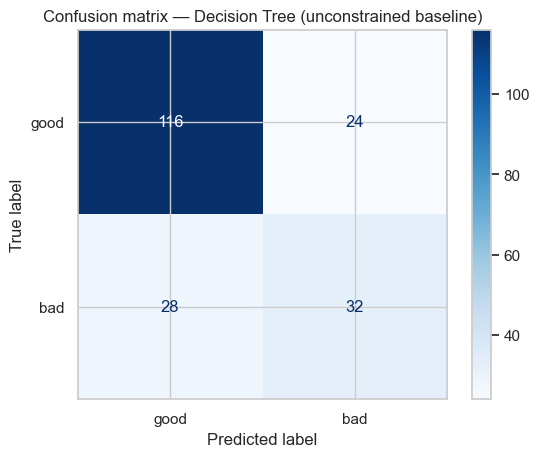

In [11]:
from sklearn.tree import DecisionTreeClassifier

baseline = DecisionTreeClassifier(random_state=42)  # fully grown, unconstrained
baseline.fit(X_train, y_train)

print(f"Unconstrained tree depth: {baseline.get_depth()}, leaves: {baseline.get_n_leaves()}")
y_pred = baseline.predict(X_test)
y_proba = baseline.predict_proba(X_test)[:, 1]
evaluate(baseline, X_test, y_test, y_pred, y_proba, label="Decision Tree (unconstrained baseline)")


## Regularization — pruning

The unconstrained baseline above is overfitting in its purest form: depth 21
and 182 leaves on 800 training rows. Two families of "pruning" control that
complexity:

**Pre-pruning** (stop growing early) via constraints checked *while*
building the tree:
- `max_depth` — hard cap on how many splits deep the tree can go.
- `min_samples_split` / `min_samples_leaf` — refuse to split a node (or
  create a leaf) with too few samples, which prevents the tree from
  carving out rules that fit just one or two training points.
- `max_leaf_nodes` — caps the total number of leaves.

**Post-pruning** (grow fully, then trim back) via **cost-complexity
pruning**: grow the full tree, then repeatedly remove the subtree that adds
the *least* value per unit of complexity, controlled by a single parameter
`ccp_alpha`. The tree's effective cost function becomes:

$$R_\alpha(T) = R(T) + \alpha \cdot |\tilde{T}|$$

where $R(T)$ is the tree's misclassification cost, $|\tilde{T}|$ is the
number of leaves, and $\alpha$ penalizes complexity — larger `ccp_alpha`
means more aggressive pruning, i.e. more regularization.


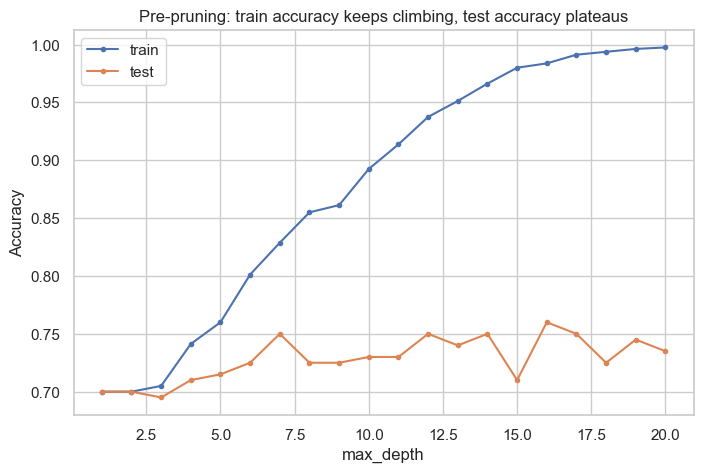

In [12]:
from sklearn.metrics import accuracy_score

depths = np.arange(1, 21)
train_acc, test_acc = [], []

for d in depths:
    tree = DecisionTreeClassifier(max_depth=d, random_state=42)
    tree.fit(X_train, y_train)
    train_acc.append(accuracy_score(y_train, tree.predict(X_train)))
    test_acc.append(accuracy_score(y_test, tree.predict(X_test)))

plt.figure(figsize=(8, 5))
plt.plot(depths, train_acc, marker=".", label="train")
plt.plot(depths, test_acc, marker=".", label="test")
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Pre-pruning: train accuracy keeps climbing, test accuracy plateaus")
plt.legend()
plt.show()


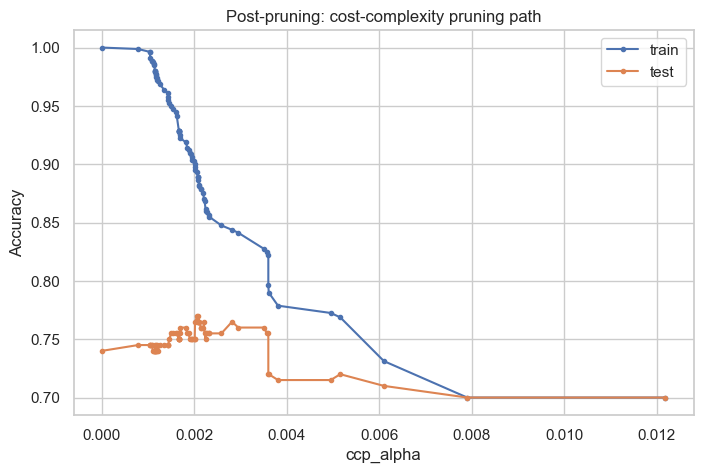

In [13]:
path = DecisionTreeClassifier(random_state=42).cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas[:-1]  # drop the trivial single-node tree at the largest alpha

train_acc, test_acc = [], []
for alpha in ccp_alphas:
    tree = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
    tree.fit(X_train, y_train)
    train_acc.append(accuracy_score(y_train, tree.predict(X_train)))
    test_acc.append(accuracy_score(y_test, tree.predict(X_test)))

plt.figure(figsize=(8, 5))
plt.plot(ccp_alphas, train_acc, marker=".", label="train")
plt.plot(ccp_alphas, test_acc, marker=".", label="test")
plt.xlabel("ccp_alpha")
plt.ylabel("Accuracy")
plt.title("Post-pruning: cost-complexity pruning path")
plt.legend()
plt.show()


Both sweeps reach the same conclusion from opposite directions — the depth
sweep constrains growth up front, the `ccp_alpha` sweep trims a fully grown
tree back — and both put peak test performance well short of the
unconstrained tree. The search below settles on `max_depth=6` with
`criterion="entropy"`.


## Hyperparameter search

Hyperparameters (`C`, `k`, `max_depth`, ...) are fixed before training, unlike
the weights the fit itself learns. All of them are selected here with **5-fold
cross-validation on the training set only**, scored on ROC-AUC: every
candidate setting is fit on four folds and scored on the fifth, rotating
through all five, and the averaged score decides the winner. The test set
takes no part in the search, which is what keeps the final numbers reported
after it meaningful.

`GridSearchCV` is used where the space is small enough to enumerate
exhaustively and `RandomizedSearchCV` where it is not — sampling a fixed
number of random combinations reaches a near-equivalent setting far more
cheaply once several hyperparameters turn out to barely move the score.


Best params: {'criterion': 'entropy', 'max_depth': 6, 'min_samples_leaf': 1}
Best CV ROC-AUC: 0.726
--- Decision Tree (tuned) ---
              precision    recall  f1-score   support

   good risk       0.78      0.83      0.81       140
    bad risk       0.54      0.47      0.50        60

    accuracy                           0.72       200
   macro avg       0.66      0.65      0.65       200
weighted avg       0.71      0.72      0.71       200

ROC-AUC: 0.719


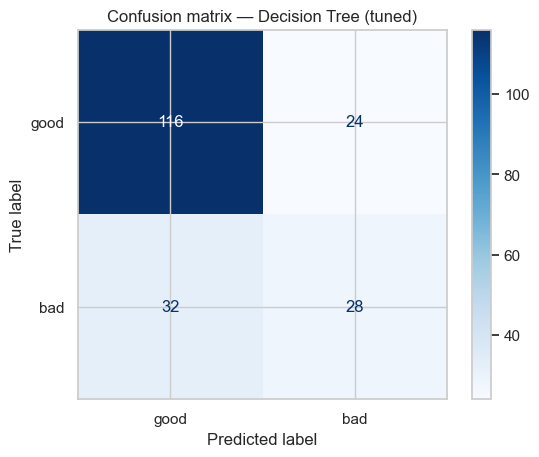

In [14]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "max_depth": [3, 4, 5, 6, 8, 10, None],
    "min_samples_leaf": [1, 2, 5, 10, 20],
    "criterion": ["gini", "entropy"],
}

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42), param_grid=param_grid,
    scoring="roc_auc", cv=5, n_jobs=-1,
)
grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print(f"Best CV ROC-AUC: {grid.best_score_:.3f}")

best_tree = grid.best_estimator_
y_pred = best_tree.predict(X_test)
y_proba = best_tree.predict_proba(X_test)[:, 1]
evaluate(best_tree, X_test, y_test, y_pred, y_proba, label="Decision Tree (tuned)")


## A quick look inside the tree

Interpretability is this model's one real advantage over the ensembles in
notebooks 06-07: the fitted rules can be read off directly. The tree plotted
below is capped at depth 3 purely so the labels stay legible — it is a
stand-in for readability, not the tuned model.


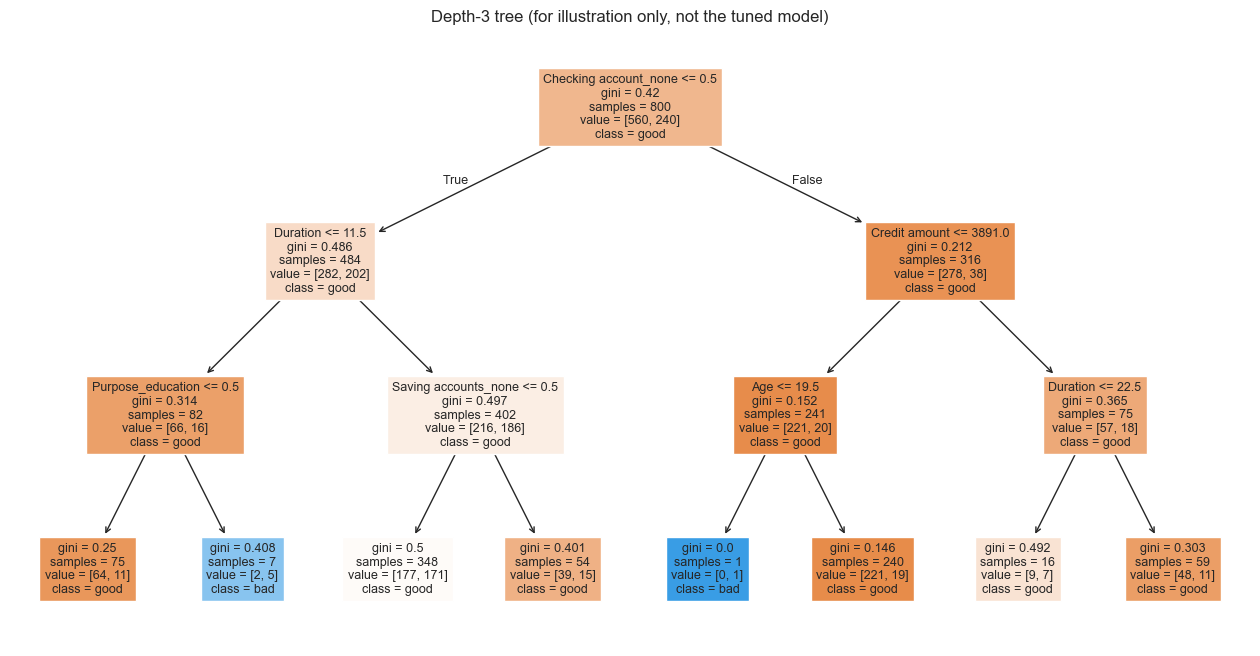

In [15]:
from sklearn.tree import plot_tree

viz_tree = DecisionTreeClassifier(max_depth=3, random_state=42)
viz_tree.fit(X_train, y_train)

plt.figure(figsize=(16, 8))
plot_tree(viz_tree, feature_names=X_train.columns, class_names=["good", "bad"],
          filled=True, fontsize=9)
plt.title("Depth-3 tree (for illustration only, not the tuned model)")
plt.show()


## Decision threshold tuning

Every model in this project exposes a predicted probability `P(bad | x)` as
well as a hard label. `.predict()` converts one into the other at a fixed
cutoff of **0.5**: `P(bad) >= 0.5` becomes "bad risk".

0.5 is a library default, not a decision that belongs to this problem, and
two things make it the wrong cutoff here:

1. **Class imbalance.** Only ~30% of these applicants defaulted, so the model
   has to be unusually confident before `P(bad)` clears 0.5. The default
   cutoff quietly favours the majority "good" class and suppresses recall on
   exactly the class a lender needs to catch. (`class_weight="balanced"` is
   the other lever for this and moves roughly the same boundary, but it
   requires retraining.)
2. **Asymmetric costs.** Approving a loan that defaults costs the outstanding
   principal; declining an applicant who would have repaid costs only the
   foregone interest. Those are not the same number, which makes the cutoff a
   business parameter rather than a technicality — and moving it walks the
   model along its existing ROC / precision-recall curve without retraining
   anything.

Two reference cutoffs are computed below:

- **Youden's J** (`J = TPR - FPR`) on the ROC curve — the cutoff that
  separates the classes best when both error types are weighted equally.
- **F1-optimal** on the precision-recall curve — the cutoff that balances
  precision and recall on the positive class, the more informative of the two
  curves under this much imbalance.

> **Methodology caveat — both cutoffs below are selected on the test set,
> which is test-set leakage.**
>
> The scan maximises J / F1 over the held-out data itself, so the test set has
> informed a modelling decision and the two tuned rows are optimistic: they
> are not a clean estimate of how that cutoff would generalise. The step is
> kept because what is being recorded is the *size* of the precision/recall
> shift a cutoff can produce, not the specific threshold value.
>
> This is not how the cutoff would be set in production. There it would be
> chosen on data the model is not being judged on — a separate validation
> fold, or out-of-fold predictions from cross-validation — and then settled in
> deployment: shadow-score live applications for some days or weeks, watch the
> realised default rate against the approval rate, and adjust the cutoff by
> trial and error until it sits where the business wants it. The threshold is
> an operational dial that gets revisited, not a number frozen at training
> time.


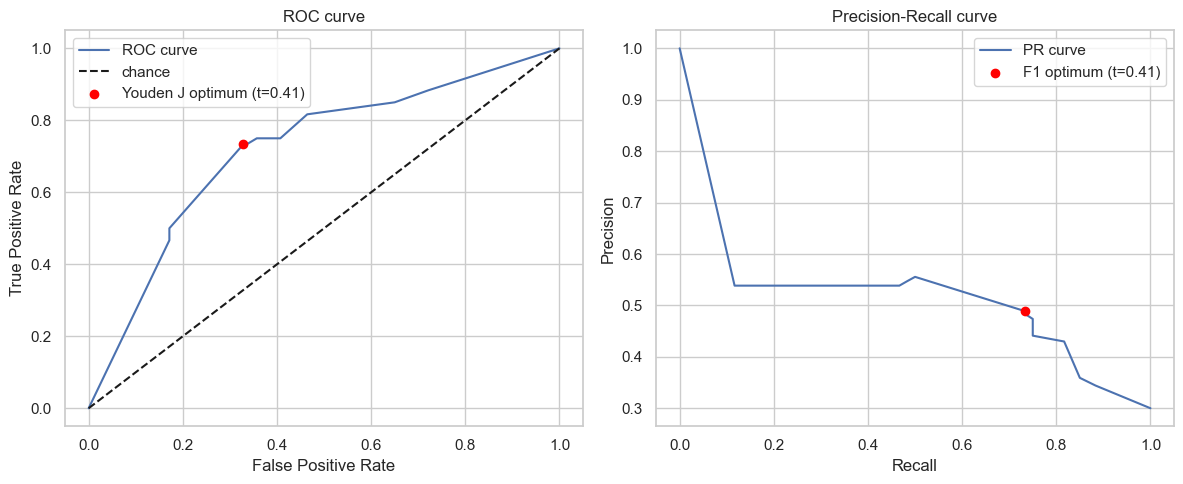

Youden's J optimal threshold: 0.410
F1-optimal threshold:         0.410


,threshold,accuracy,precision,recall,f1
default (0.5),0.500000,0.725,0.547170,0.483333,0.513274
Youden's J,0.409639,0.690,0.488889,0.733333,0.586667
F1-optimal,0.409639,0.690,0.488889,0.733333,0.586667


In [8]:
from sklearn.metrics import roc_curve, precision_recall_curve, f1_score

y_proba_best = best_tree.predict_proba(X_test)[:, 1]

# --- ROC curve & Youden's J statistic -------------------------------------
fpr, tpr, roc_thresholds = roc_curve(y_test, y_proba_best)
j_scores = tpr - fpr
best_j_idx = np.argmax(j_scores)
best_j_threshold = roc_thresholds[best_j_idx]

# --- Precision-Recall curve & F1-optimal threshold -------------------------
precision, recall, pr_thresholds = precision_recall_curve(y_test, y_proba_best)
f1_scores = np.divide(
    2 * precision * recall, precision + recall,
    out=np.zeros_like(precision), where=(precision + recall) != 0
)
best_f1_idx = np.argmax(f1_scores[:-1])  # last point has no matching threshold
best_f1_threshold = pr_thresholds[best_f1_idx]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(fpr, tpr, label="ROC curve")
axes[0].plot([0, 1], [0, 1], "k--", label="chance")
axes[0].scatter(fpr[best_j_idx], tpr[best_j_idx], color="red", zorder=5,
                 label=f"Youden J optimum (t={best_j_threshold:.2f})")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC curve")
axes[0].legend()

axes[1].plot(recall, precision, label="PR curve")
axes[1].scatter(recall[best_f1_idx], precision[best_f1_idx], color="red", zorder=5,
                 label=f"F1 optimum (t={best_f1_threshold:.2f})")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall curve")
axes[1].legend()
plt.tight_layout()
plt.show()

print(f"Youden's J optimal threshold: {best_j_threshold:.3f}")
print(f"F1-optimal threshold:         {best_f1_threshold:.3f}")


def metrics_at_threshold(y_true, proba, threshold):
    preds = (proba >= threshold).astype(int)
    return {
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, preds),
        "precision": precision_score(y_true, preds, zero_division=0),
        "recall": recall_score(y_true, preds, zero_division=0),
        "f1": f1_score(y_true, preds, zero_division=0),
    }


results = pd.DataFrame([
    metrics_at_threshold(y_test, y_proba_best, 0.5),
    metrics_at_threshold(y_test, y_proba_best, best_j_threshold),
    metrics_at_threshold(y_test, y_proba_best, best_f1_threshold),
], index=["default (0.5)", "Youden's J", "F1-optimal"])

results


## Summary

- The unconstrained tree grew to depth 21 with 182 leaves and scored ROC-AUC
  **0.681**, the worst in the project, while its accuracy of 0.74 still looked
  respectable. Pruning is not an optimisation here, it is a requirement.
- Pre-pruning (`max_depth`, `min_samples_leaf`) and post-pruning (`ccp_alpha`)
  reach the same bias-variance tradeoff from opposite ends. The search chose
  pre-pruning at `max_depth=6` with `criterion="entropy"`, lifting test ROC-AUC
  to **0.719**.
- Even tuned, the single tree trails both ensembles (Random Forest 0.781,
  XGBoost 0.772). What it keeps instead is readability: the depth-3 plot above
  is an entire model expressed as a rule set, which neither ensemble can
  offer.
- At `t = 0.41`, recall on defaulters rises 0.48 -> 0.73 for 3.5 points of
  accuracy. That cutoff was selected on the test set; see the caveat above.
